In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

[[1.99816048 1.91131728]
 [4.30285723 1.25578619]
 [3.42797577 1.09757739]
 [2.89463394 2.42332831]
 [1.12407456 2.44844805]
 [1.12397808 2.21259602]
 [0.73233445 1.45692065]
 [3.96470458 1.14650817]
 [2.90446005 2.02634954]
 [3.33229031 1.66022874]
 [0.58233798 1.18305735]
 [4.37963941 1.74276537]
 [3.82977056 1.05158278]
 [1.34935644 2.3639806 ]
 [1.22729987 1.38816997]
 [1.23361804 1.99378343]
 [1.71696897 1.46756661]
 [2.59902573 1.78010203]
 [2.22778007 1.82006542]
 [1.66491656 1.27728168]
 [2.94741158 2.45437694]
 [1.05797544 2.16269924]
 [1.66857859 2.40924841]
 [1.96544737 2.34224103]
 [2.32427994 1.89684997]
 [3.64070385 2.38281135]
 [1.29869513 1.13273875]
 [2.55693775 1.29397429]
 [2.86965828 1.06784093]
 [0.68580165 1.4879955 ]]
mean [2.25438909 1.7446064 ]
variance [1.23352859 0.23557355]


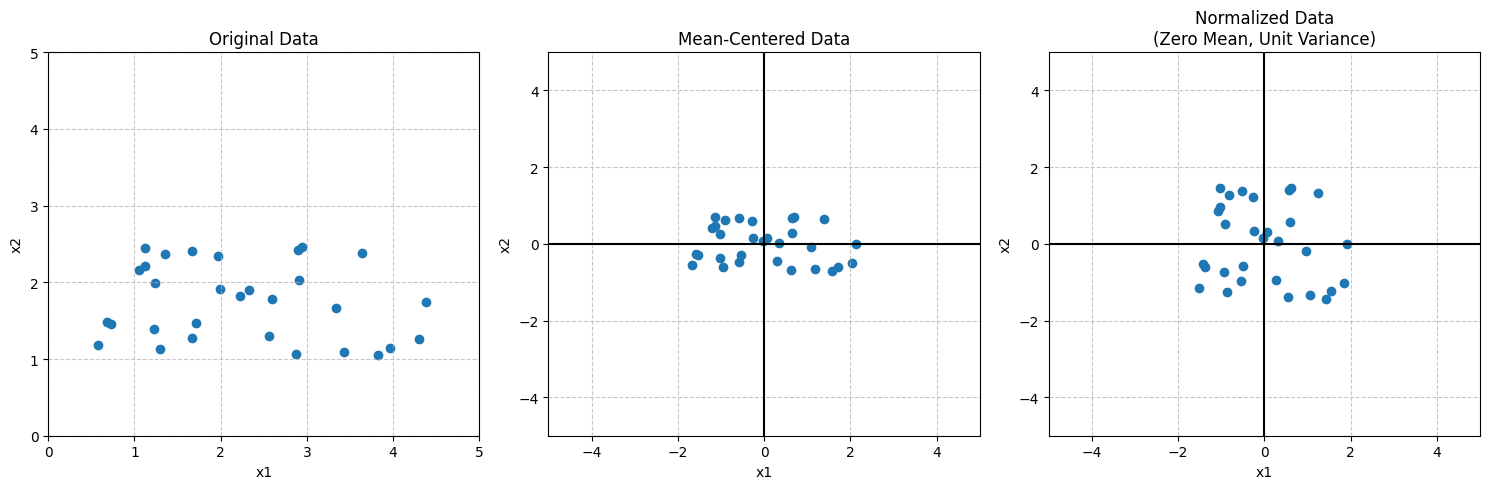


Dataset Statistics:

Original Data:
Mean: [2.25438909 1.7446064 ]
Std: [1.11064332 0.48535919]

Mean-Centered Data:
Mean: [ 2.22044605e-16 -2.22044605e-16]
Std: [1.11064332 0.48535919]

Normalized Data:
Mean: [ 2.22044605e-16 -4.73695157e-16]
Std: [1. 1.]


In [ ]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic dataset
n_samples = 30
x1 = np.random.uniform(0.5, 4.5, n_samples)
x2 = np.random.uniform(1, 2.5, n_samples)
X = np.column_stack((x1, x2))

# Create figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Original data
ax1.scatter(X[:, 0], X[:, 1])

ax1.set_title('Original Data')
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_xlim(0, 5)
ax1.set_ylim(0, 5)
ax1.grid(True, linestyle='--', alpha=0.7)

# Calculate and subtract mean
mean = 1/n_samples * np.sum(X, axis=0)
X_centered = X - mean

print(X)
print("mean", mean)

# Plot 2: Mean-centered data
ax2.scatter(X_centered[:, 0], X_centered[:, 1])

ax2.set_title('Mean-Centered Data')
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.set_xlim(-5, 5)
ax2.set_ylim(-5, 5)
ax2.axhline(y=0, color='k')
ax2.axvline(x=0, color='k')

# Normalize (zero mean and unit variance)
variance = 1/n_samples * np.sum(X_centered**2, axis=0)
X_normalized = X_centered / np.sqrt(variance)
print("variance", variance)

# Plot 3: Normalized data
ax3.scatter(X_normalized[:, 0], X_normalized[:, 1])

ax3.set_title('Normalized Data\n(Zero Mean, Unit Variance)')
ax3.set_xlabel('x1')
ax3.set_ylabel('x2')
ax3.set_xlim(-5, 5)
ax3.set_ylim(-5, 5)
ax3.grid(True, linestyle='--', alpha=0.7)
ax3.axhline(y=0, color='k')
ax3.axvline(x=0, color='k')

# Adjust layout and display
plt.tight_layout()
plt.show()

# Print statistics for verification
print("\nDataset Statistics:")
print("\nOriginal Data:")
print(f"Mean: {X.mean(axis=0)}")
print(f"Std: {X.std(axis=0)}")

print("\nMean-Centered Data:")
print(f"Mean: {X_centered.mean(axis=0)}")
print(f"Std: {X_centered.std(axis=0)}")

print("\nNormalized Data:")
print(f"Mean: {X_normalized.mean(axis=0)}")
print(f"Std: {X_normalized.std(axis=0)}")

In [ ]:
def normalize_image_dataset(dataset):
  """Normalizes an image dataset by subtracting the mean and dividing by the standard deviation.

  Args:
    dataset: A numpy array of shape (n_samples, w, h, c) representing an RGB image dataset.

  Returns:
    A numpy array of the same shape as the input dataset, with normalized values.
  """

  mean = np.mean(dataset)
  print("mean:", mean)
  std = np.std(dataset)
  print("std:", std)
  normalized_dataset = (dataset - mean) / std
  return normalized_dataset

In [ ]:
# Load the MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist['data'], mnist['target']

# Show one example
print(X.shape)
# print(X[0])

# Convert the data to a numpy array and reshape to image dimensions
X = X.reshape(-1, 28, 28, 1)

# Normalize the dataset using the normalize_image_dataset function
normalized_X = normalize_image_dataset(X)

# Show one flatted normalized example
print(normalized_X.shape)
# print(normalized_X[0].flatten())

# Print some statistics of the normalized dataset
print("Mean of normalized dataset:", np.mean(normalized_X))
print("Standard deviation of normalized dataset:", np.std(normalized_X))

(70000, 784)
mean: 33.385964741253645
std: 78.65437362689433
(70000, 28, 28, 1)
Mean of normalized dataset: -9.261541323297292e-16
Standard deviation of normalized dataset: 0.9999999999999903


In [ ]:
def input_norm(X, epsilon=1e-8):
  m = X.shape[1]

  mean = 1/m * np.sum(X, axis=1, keepdims=True)
  print("mean", mean)

  variance = 1/m * np.sum((X - mean)**2, axis=1, keepdims=True)
  print("variance", variance)

  X_norm = (X - mean)/(np.sqrt(variance) + epsilon)

  return X_norm

X = np.array([[152 ,  229,   84, 95],
              [4   ,    3,    1, 3],
              [7200, 3000, 1500, 12000]])

print("X", X)

X_norm = input_norm(X)
print("X_norm", X_norm)
print(X_norm.T)

X [[  152   229    84    95]
 [    4     3     1     3]
 [ 7200  3000  1500 12000]]
mean [[1.400e+02]
 [2.750e+00]
 [5.925e+03]]
variance [[3.3065000e+03]
 [1.1875000e+00]
 [1.6666875e+07]]
X_norm [[ 0.20868776  1.54776757 -0.97387622 -0.78257911]
 [ 1.14707866  0.22941573 -1.60591012  0.22941573]
 [ 0.31230799 -0.71647127 -1.08389244  1.48805572]]
[[ 0.20868776  1.14707866  0.31230799]
 [ 1.54776757  0.22941573 -0.71647127]
 [-0.97387622 -1.60591012 -1.08389244]
 [-0.78257911  0.22941573  1.48805572]]


In [ ]:
# Set random seed for reproducibility
np.random.seed(42)

def forward(X, W, b):
  return np.dot(W, X) + b

def batch_norm(Z, gamma, beta, epsilon=1e-8):
  m = Z.shape[1]

  mean = 1/m * np.sum(Z, axis=1, keepdims=True)
  print("mean", mean)

  variance = 1/m * np.sum((Z - mean)**2, axis=1, keepdims=True)
  print("variance", variance)

  Z_norm = (Z - mean)/(np.sqrt(variance) + epsilon)
  print("z_norm", Z_norm)

  return gamma * Z_norm + beta

m = 4
d = 3

n0 = d
n1 = 3
n2 = 2

gamma = np.ones((n1, 1))
beta = np.zeros((n1, 1))

X = np.array([
        [1.0, 2.0, -1.0, 0.0],
        [0.5, 1.0, 0.5, -1.0],
        [0.0, 0.0, 1.0, -0.5]])

print("X", X)

# X_norm = input_norm(X)
# print("X_norm", X_norm)

# Initialize layer parameters
W1 = np.array([
  [0.1, 0.2, -0.1],
  [-0.2, 0.1, 0.2],
  [0.1, -0.1, 0.1   ],
])

b1 = np.zeros((n1, 1))

# Forward pass
Z1 = forward(X, W1, b1)
print("Z1", Z1)

# Batch normalization
Z1_bach_norm = batch_norm(Z1, gamma, beta)
# print(Z1_bach_norm)

X [[ 1.   2.  -1.   0. ]
 [ 0.5  1.   0.5 -1. ]
 [ 0.   0.   1.  -0.5]]
Z1 [[ 0.2   0.4  -0.1  -0.15]
 [-0.15 -0.3   0.45 -0.2 ]
 [ 0.05  0.1  -0.05  0.05]]
mean [[ 0.0875]
 [-0.05  ]
 [ 0.0375]]
variance [[0.05046875]
 [0.08625   ]
 [0.00296875]]
z_norm [[ 0.50077337  1.39103715 -0.83462229 -1.05718823]
 [-0.3405026  -0.8512565   1.702513   -0.5107539 ]
 [ 0.22941569  1.14707846 -1.60590984  0.22941569]]


In [ ]:
# Set random seed for reproducibility
np.random.seed(42)

def forward(X, W, b):
  return np.dot(W, X) + b

def layer_norm(Z, alpha, beta, epsilon=1e-8):
  n = Z.shape[0]

  mean = 1/n * np.sum(Z, axis=0, keepdims=True)
  print("mean", mean)

  variance = 1/n * np.sum((Z - mean)**2, axis=0, keepdims=True)
  print("variance", variance)

  Z_norm = (Z - mean)/(np.sqrt(variance) + epsilon)
  print("z_norm", Z_norm)

  return alpha * Z_norm + beta

m = 4
d = 3

n0 = d
n1 = 3
n2 = 2

gamma = np.ones((n1, 1))
beta = np.zeros((n1, 1))

X = np.array([
        [1.0, 2.0, -1.0, 0.0],
        [0.5, 1.0, 0.5, -1.0],
        [0.0, 0.0, 1.0, -0.5]])

print("X", X)

# X_norm = input_norm(X)
# print("X_norm", X_norm)

# Initialize layer parameters
W1 = np.array([
  [0.1, 0.2, -0.1],
  [-0.2, 0.1, 0.2],
  [0.1, -0.1, 0.1],
])

b1 = np.zeros((n1, 1))

# Forward pass
Z1 = forward(X, W1, b1)
print("Z1", Z1)

# Batch normalization
Z1_bach_norm = layer_norm(Z1, gamma, beta)
# print(Z1_bach_norm)

X [[ 1.   2.  -1.   0. ]
 [ 0.5  1.   0.5 -1. ]
 [ 0.   0.   1.  -0.5]]
Z1 [[ 0.2   0.4  -0.1  -0.15]
 [-0.15 -0.3   0.45 -0.2 ]
 [ 0.05  0.1  -0.05  0.05]]
mean [[ 0.03333333  0.06666667  0.1        -0.1       ]]
variance [[0.02055556 0.08222222 0.06166667 0.01166667]]
z_norm [[ 1.16247631  1.16247635 -0.80538723 -0.46291001]
 [-1.27872394 -1.27872398  1.40942766 -0.92582001]
 [ 0.11624763  0.11624763 -0.60404043  1.38873002]]
